# Exemplo modelo risco de crédito

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve

from lightgbm import LGBMClassifier

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [8]:
def gerar_base(n=20000, seed=42, safra_inicial="2024-01"):
    rng = np.random.default_rng(seed)

    idade        = rng.integers(20, 71, n)
    tempo_casa   = rng.integers(1, 121, n)
    renda        = np.exp(rng.normal(8.3, 0.55, n)).clip(1200, 60000)
    utilizacao   = rng.beta(2, 3, n)
    atrasos_12m  = rng.poisson(0.8, n).clip(0, 12)
    atraso_max   = (atrasos_12m * rng.integers(5, 35, n)).clip(0, 180)
    n_produtos   = rng.integers(1, 7, n)
    consultas_6m = rng.poisson(1.2, n).clip(0, 15)
    regiao = rng.choice(["SE","S","NE","CO","N"], n, p=[.45,.18,.22,.09,.06])
    canal  = rng.choice(["APP","AGENCIA","PARCEIRO"], n, p=[.55,.25,.20])

    limite = (renda * rng.uniform(1.0, 4.0, n)).clip(1000, 120000)
    ead    = (limite * utilizacao).clip(300, None)          # exposição no default
    dti    = (ead / (renda * 12)).clip(0, 3)                # endividamento

    # ---- mecanismo causal (o "mundo real" que o modelo deve descobrir) ----
    logit = (
        -3.55
        + 3.60  * utilizacao          # uso alto do limite = sinal forte
        + 0.42  * atrasos_12m         # comportamento passado manda
        + 0.016 * atraso_max
        + 1.90  * dti                 # capacidade de pagamento
        + 0.30  * consultas_6m        # busca por crédito = estresse
        - 0.030 * (idade - 20)
        - 0.016 * tempo_casa          # relacionamento reduz risco
        - 0.14  * n_produtos
        - 0.70  * (renda > 9000)
        + 0.45  * (canal == "PARCEIRO")
    )
    p_real  = 1 / (1 + np.exp(-logit))
    default = rng.binomial(1, p_real)

    # safras mensais -> permite split out-of-time
    safras = pd.period_range(safra_inicial, periods=12, freq="M")
    safra  = rng.choice(safras.astype(str), n)

    df = pd.DataFrame({
        "customer_id": np.arange(1, n+1),
        "safra": safra,
        "idade": idade,
        "tempo_casa_meses": tempo_casa,
        "renda_mensal": renda.round(2),
        "utilizacao_limite": utilizacao.round(4),
        "atrasos_12m": atrasos_12m,
        "atraso_max_dias": atraso_max,
        "n_produtos": n_produtos,
        "consultas_bureau_6m": consultas_6m,
        "dti": dti.round(4),
        "limite_aprovado": limite.round(2),
        "ead": ead.round(2),
        "regiao": regiao,
        "canal_aquisicao": canal,
        "pd_real": p_real.round(5),      # só para diagnóstico, NUNCA como feature
        "default": default,
    })

    # dados faltantes realistas (renda não informada)
    faltantes = rng.choice(n, int(0.04*n), replace=False)
    df.loc[faltantes, "renda_mensal"] = np.nan
    return df

df = gerar_base()
print(f"Registros: {len(df):,}")
print(f"Bad rate geral: {df['default'].mean():.2%}")
df.head()

Registros: 20,000
Bad rate geral: 7.71%


,customer_id,safra,idade,tempo_casa_meses,renda_mensal,utilizacao_limite,atrasos_12m,atraso_max_dias,n_produtos,consultas_bureau_6m,dti,limite_aprovado,ead,regiao,canal_aquisicao,pd_real,default
0,1,2024-01,24,5,"1,474.130",0.086,1,9,3,2,0.019,"3,885.800",333.120,CO,AGENCIA,0.065,0
1,2,2024-11,59,87,"3,238.680",0.198,2,28,6,0,0.027,"5,325.880","1,054.430",SE,AGENCIA,0.007,0
2,3,2024-05,53,26,"1,538.220",0.481,1,22,4,1,0.048,"1,850.240",890.610,SE,APP,0.068,0
3,4,2024-04,42,86,"12,367.730",0.789,0,0,6,1,0.225,"42,350.090","33,428.140",SE,APP,0.028,0
4,5,2024-12,42,68,"4,522.730",0.157,1,22,6,3,0.032,"10,985.310","1,726.110",S,APP,0.021,0


In [9]:
FEATS_NUM = ["idade","tempo_casa_meses","renda_mensal","utilizacao_limite","atrasos_12m",
             "atraso_max_dias","n_produtos","consultas_bureau_6m","dti","limite_aprovado"]
FEATS_CAT = ["regiao","canal_aquisicao"]
FEATURES  = FEATS_NUM + FEATS_CAT
TARGET    = "default"

safras = sorted(df["safra"].unique())
corte_oot = safras[9]

treino = df[df["safra"] <  corte_oot]
oot    = df[df["safra"] >= corte_oot]

X_tr, y_tr = treino[FEATURES], treino[TARGET]
X_oot, y_oot = oot[FEATURES], oot[TARGET]

print(f"Treino: {len(treino):,} | safras {safras[0]} a {safras[8]}")
print(f"OOT   : {len(oot):,} | safras {corte_oot} a {safras[-1]}")
print(f"Bad rate treino {y_tr.mean():.2%} | OOT {y_oot.mean():.2%}")

Treino: 14,958 | safras 2024-01 a 2024-09
OOT   : 5,042 | safras 2024-10 a 2024-12
Bad rate treino 7.67% | OOT 7.85%


In [10]:
pre = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), FEATS_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATS_CAT),
])

lgbm = LGBMClassifier(
    n_estimators=400, learning_rate=0.05, num_leaves=31,
    min_child_samples=40, subsample=0.9, colsample_bytree=0.9,
    random_state=RANDOM_STATE, verbose=-1,
)

base_model = Pipeline([("pre", pre), ("clf", lgbm)])

modelo = CalibratedClassifierCV(base_model, method="isotonic", cv=3)
modelo.fit(X_tr, y_tr)

pd_oot = modelo.predict_proba(X_oot)[:, 1]
print("Modelo treinado e calibrado.")

Modelo treinado e calibrado.


In [11]:
def ks_score(y_true, y_score):
    d = pd.DataFrame({"y": np.asarray(y_true), "s": np.asarray(y_score)}).sort_values("s")
    bad  = (d["y"] == 1).cumsum() / max((d["y"] == 1).sum(), 1)
    good = (d["y"] == 0).cumsum() / max((d["y"] == 0).sum(), 1)
    return float(np.max(np.abs(bad - good)) * 100)

def gini_score(auc):
    return 2*auc - 1

auc   = roc_auc_score(y_oot, pd_oot)
ks    = ks_score(y_oot, pd_oot)
brier = brier_score_loss(y_oot, pd_oot)

print(f"AUC   : {auc:.4f}")
print(f"Gini  : {gini_score(auc):.4f}")
print(f"KS    : {ks:.2f}")
print(f"Brier : {brier:.5f}")

regua = "fraco" if ks < 30 else ("aceitavel" if ks < 40 else ("bom" if ks < 50 else "excelente"))
print(f"\nLeitura de mercado do KS: {regua}")

AUC   : 0.7832
Gini  : 0.5663
KS    : 44.14
Brier : 0.06469

Leitura de mercado do KS: bom


In [12]:
def lgd_por_perfil(frame, base=0.55, teto=0.92):
    """LGD cresce com utilização de limite e histórico de atraso."""
    ajuste = 0.22*frame["utilizacao_limite"] + 0.012*frame["atrasos_12m"]
    return (base + ajuste).clip(base, teto)

MARGEM_FINANCEIRA = 0.19   # receita anual sobre a exposição
CUSTO_OPERACIONAL = 180    # custo por cliente/ano

def montar_pl(frame, pd_hat, margem=MARGEM_FINANCEIRA, custo_op=CUSTO_OPERACIONAL):
    out = frame.copy()
    out["pd"]  = pd_hat
    out["lgd"] = lgd_por_perfil(frame)

    # Perda esperada
    out["expected_loss"] = out["pd"] * out["lgd"] * out["ead"]

    # Receita: quem dá default não paga o ano inteiro -> pondera por (1 - PD)
    out["receita_esperada"] = out["ead"] * margem * (1 - out["pd"])
    out["custo_op"] = custo_op

    out["lucro_ajustado"] = (out["receita_esperada"]
                             - out["expected_loss"]
                             - out["custo_op"])
    return out

carteira = montar_pl(oot, pd_oot)

carteira[["pd","lgd","ead","expected_loss","receita_esperada","lucro_ajustado"]].describe().round(2)

,pd,lgd,ead,expected_loss,receita_esperada,lucro_ajustado
count,"5,042.000","5,042.000","5,042.000","5,042.000","5,042.000","5,042.000"
mean,0.080,0.650,"4,734.040",302.690,816.510,333.820
std,0.080,0.050,"4,638.940",589.790,798.760,745.300
min,0.000,0.550,300.000,0.000,37.940,"-6,530.580"
25%,0.020,0.610,"1,746.160",33.180,314.750,10.570
50%,0.050,0.640,"3,395.340",109.290,591.850,203.340
75%,0.090,0.680,"6,102.450",311.200,"1,041.940",528.340
max,0.740,0.780,"52,662.100","8,149.670","9,567.260","7,725.500"


In [13]:
carteira["decil_risco"] = pd.qcut(carteira["pd"], 10, labels=False, duplicates="drop") + 1

resumo = (carteira.groupby("decil_risco")
          .agg(clientes=("pd","size"),
               pd_media=("pd","mean"),
               bad_rate_real=("default","mean"),
               ead_total=("ead","sum"),
               perda_esperada=("expected_loss","sum"),
               lucro_ajustado=("lucro_ajustado","sum"))
          .round(3))

resumo["lucro_por_cliente"] = (resumo["lucro_ajustado"]/resumo["clientes"]).round(2)
resumo

,clientes,pd_media,bad_rate_real,ead_total,perda_esperada,lucro_ajustado,lucro_por_cliente
decil_risco,,,,,,,
1,506,0.007,0.006,"1,555,633.830","8,093.030","193,954.820",383.310
2,569,0.018,0.011,"1,908,940.190","21,957.676","231,783.144",407.350
3,448,0.024,0.029,"1,723,958.490","27,239.637","211,646.677",472.430
4,494,0.033,0.036,"2,050,067.470","43,447.334","244,458.579",494.860
5,506,0.043,0.032,"2,380,583.210","66,702.810","275,278.822",544.030
6,514,0.056,0.043,"2,517,144.500","95,352.815","263,270.200",512.200
7,493,0.072,0.101,"2,455,674.270","119,580.416","224,495.048",455.370
8,503,0.091,0.107,"2,657,540.330","164,332.722","204,088.352",405.740
9,504,0.135,0.125,"3,204,912.490","298,441.419","137,997.294",273.800


In [14]:
def curva_politica(tabela, grid=None):
    grid = np.arange(0.01, 0.61, 0.005) if grid is None else grid
    linhas = []
    for c in grid:
        ap = tabela[tabela["pd"] <= c]
        if len(ap) == 0:
            continue
        linhas.append({
            "corte_pd": round(float(c), 4),
            "taxa_aprovacao": len(ap)/len(tabela),
            "bad_rate_aprovados": ap["default"].mean(),
            "perda_esperada": ap["expected_loss"].sum(),
            "lucro_total": ap["lucro_ajustado"].sum(),
        })
    return pd.DataFrame(linhas)

curva = curva_politica(carteira)
melhor = curva.loc[curva["lucro_total"].idxmax()]

lucro_sem_politica = carteira["lucro_ajustado"].sum()
ganho = melhor["lucro_total"] - lucro_sem_politica

print(f"Corte ótimo de PD        : {melhor['corte_pd']:.3f}")
print(f"Taxa de aprovação        : {melhor['taxa_aprovacao']:.1%}")
print(f"Bad rate dos aprovados   : {melhor['bad_rate_aprovados']:.2%}")
print(f"Lucro com política       : R$ {melhor['lucro_total']:,.2f}")
print(f"Lucro aprovando todos    : R$ {lucro_sem_politica:,.2f}")
print(f"Ganho da política        : R$ {ganho:,.2f}  ({ganho/abs(lucro_sem_politica):.1%})")

Corte ótimo de PD        : 0.185
Taxa de aprovação        : 91.6%
Bad rate dos aprovados   : 5.65%
Lucro com política       : R$ 1,989,825.19
Lucro aprovando todos    : R$ 1,683,141.85
Ganho da política        : R$ 306,683.34  (18.2%)


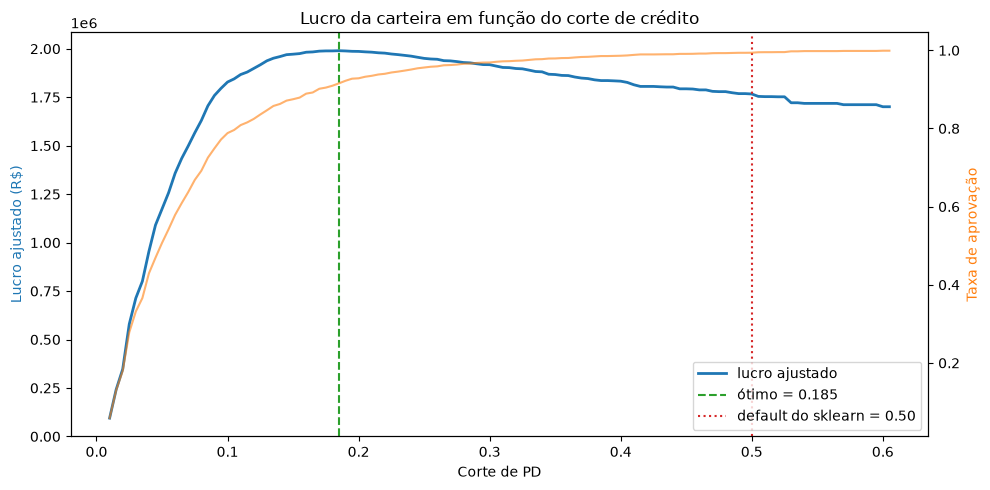

In [15]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(curva["corte_pd"], curva["lucro_total"], lw=2, color="tab:blue", label="lucro ajustado")
ax1.axvline(melhor["corte_pd"], color="tab:green", ls="--", label=f"ótimo = {melhor['corte_pd']:.3f}")
ax1.axvline(0.50, color="tab:red", ls=":", label="default do sklearn = 0.50")
ax1.set_xlabel("Corte de PD"); ax1.set_ylabel("Lucro ajustado (R$)", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(curva["corte_pd"], curva["taxa_aprovacao"], color="tab:orange", alpha=.6, label="aprovação")
ax2.set_ylabel("Taxa de aprovação", color="tab:orange")

ax1.set_title("Lucro da carteira em função do corte de crédito")
ax1.legend(loc="lower right")
plt.tight_layout(); plt.show()

In [16]:
def politica_faixas(pd_valor):
    if pd_valor <= 0.03:  return "A - aprovar com limite ampliado"
    if pd_valor <= 0.08:  return "B - aprovar limite padrão"
    if pd_valor <= 0.15:  return "C - aprovar limite reduzido"
    if pd_valor <= 0.30:  return "D - análise manual / garantia"
    return "E - recusar"

carteira["faixa"] = carteira["pd"].apply(politica_faixas)

painel = (carteira.groupby("faixa")
          .agg(clientes=("pd","size"),
               pd_media=("pd","mean"),
               bad_rate=("default","mean"),
               ead_total=("ead","sum"),
               lucro_ajustado=("lucro_ajustado","sum"))
          .sort_index()
          .round(3))

painel["% carteira"] = (painel["clientes"]/painel["clientes"].sum()*100).round(1)
painel

,clientes,pd_media,bad_rate,ead_total,lucro_ajustado,% carteira
faixa,,,,,,
A - aprovar com limite ampliado,1672,0.017,0.016,"5,809,347.010","713,493.088",33.200
B - aprovar limite padrão,1816,0.052,0.054,"8,591,657.570","916,215.849",36.000
C - aprovar limite reduzido,923,0.105,0.114,"5,272,828.790","342,166.099",18.300
D - análise manual / garantia,474,0.201,0.224,"3,095,044.330","-54,155.803",9.400
E - recusar,157,0.409,0.389,"1,100,139.770","-234,577.380",3.100


In [17]:
def psi(esperado, observado, bins=10):
    cortes = np.quantile(esperado, np.linspace(0, 1, bins+1))
    cortes[0], cortes[-1] = -np.inf, np.inf
    e = np.histogram(esperado, bins=cortes)[0] / len(esperado)
    o = np.histogram(observado, bins=cortes)[0] / len(observado)
    e, o = np.clip(e, 1e-6, None), np.clip(o, 1e-6, None)
    return float(np.sum((o - e) * np.log(o/e)))


def safra_com_choque(n=8000, seed=7, choque=1.0):
    """Choque macro: mais uso de limite, mais atrasos, renda real menor."""
    nova = gerar_base(n=n, seed=seed)
    nova["utilizacao_limite"] = (nova["utilizacao_limite"] + 0.12*choque).clip(0, 1)
    nova["atrasos_12m"]       = (nova["atrasos_12m"] + np.round(1.2*choque)).clip(0, 12)
    nova["renda_mensal"]      = nova["renda_mensal"] * (1 - 0.10*choque)
    nova["dti"] = (nova["ead"] / (nova["renda_mensal"]*12)).clip(0, 3)
    return nova


linhas = []
for choque in [0.0, 0.5, 1.0, 1.5]:
    nova = safra_com_choque(choque=choque)
    pd_nova = modelo.predict_proba(nova[FEATURES])[:, 1]
    valor_psi = psi(pd_oot, pd_nova)
    status = ("estável" if valor_psi < 0.10
              else "atenção" if valor_psi < 0.25
              else "RECALIBRAR")
    linhas.append({
        "choque_macro": choque,
        "psi": round(valor_psi, 4),
        "pd_media": round(pd_nova.mean(), 4),
        "el_total": round((pd_nova * lgd_por_perfil(nova) * nova["ead"]).sum(), 2),
        "status": status,
    })

pd.DataFrame(linhas)

,choque_macro,psi,pd_media,el_total,status
0,0.000,0.003,0.076,"2,385,005.810",estável
1,0.500,0.123,0.105,"3,379,282.520",atenção
2,1.000,0.232,0.117,"3,789,329.090",atenção
3,1.500,0.791,0.162,"5,270,777.320",RECALIBRAR


In [18]:
HORIZONTE_ANOS = 3
TAXA_DESCONTO  = 0.10

# CLV simplificado: margem anual descontada, ponderada por sobrevivência ao default
fluxo_anual = carteira["ead"] * MARGEM_FINANCEIRA - CUSTO_OPERACIONAL
fatores = sum(((1 - carteira["pd"])**t) / ((1 + TAXA_DESCONTO)**t)
              for t in range(1, HORIZONTE_ANOS + 1))

carteira["clv"]  = fluxo_anual * fatores
carteira["el_horizonte"] = carteira["expected_loss"] * HORIZONTE_ANOS * 0.7  # perda decai
carteira["rclv"] = carteira["clv"] - carteira["el_horizonte"]

carteira["seg_valor"] = np.where(carteira["clv"] >= carteira["clv"].median(), "CLV alto", "CLV baixo")
carteira["seg_risco"] = np.where(carteira["pd"] <= carteira["pd"].median(), "risco baixo", "risco alto")

matriz = (carteira.pivot_table(index="seg_valor", columns="seg_risco",
                               values="rclv", aggfunc=["mean","count"])
          .round(2))
matriz

mean                  count            
seg_risco risco alto risco baixo risco alto risco baixo
seg_valor                                              
CLV alto   1,004.420   2,530.040       1505        1016
CLV baixo    -72.640     209.580       1014        1507

Correlação PD prevista x PD real: 0.8919


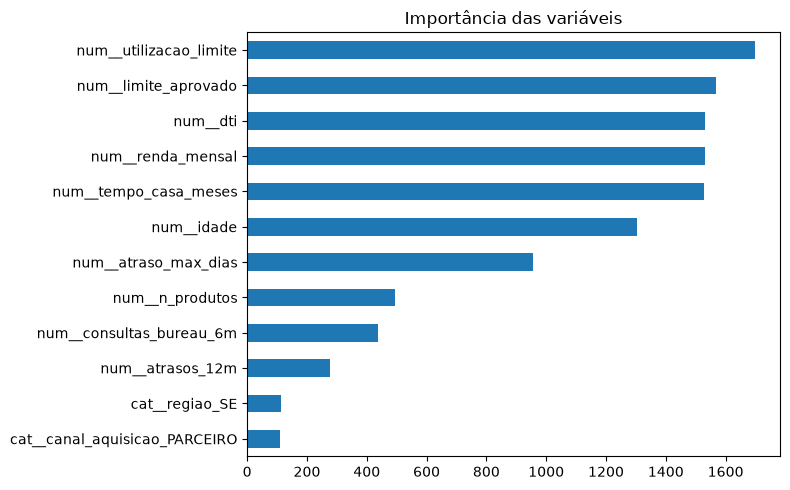

In [19]:
corr = np.corrcoef(carteira["pd"], carteira["pd_real"])[0, 1]
print(f"Correlação PD prevista x PD real: {corr:.4f}")

estimador = modelo.calibrated_classifiers_[0].estimator
nomes = estimador.named_steps["pre"].get_feature_names_out()
imp = pd.Series(estimador.named_steps["clf"].feature_importances_, index=nomes)

top = imp.sort_values(ascending=False).head(12)
top.sort_values().plot(kind="barh", figsize=(8, 5), title="Importância das variáveis")
plt.tight_layout(); plt.show()

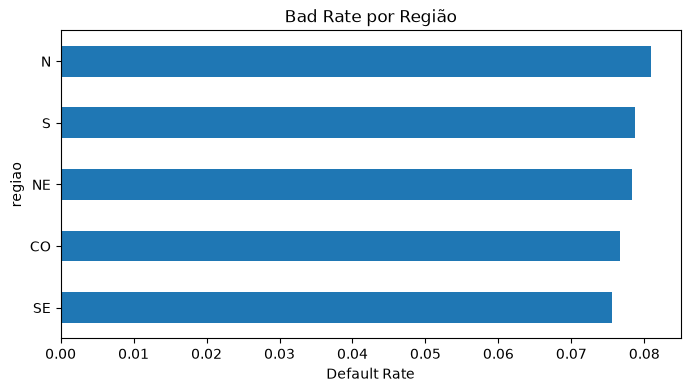

In [22]:
import matplotlib.pyplot as plt

(
    df.groupby("regiao")["default"]
    .mean()
    .sort_values()
    .plot(
        kind="barh",
        figsize=(8,4)
    )
)

plt.title(
    "Bad Rate por Região"
)

plt.xlabel("Default Rate")

plt.show()

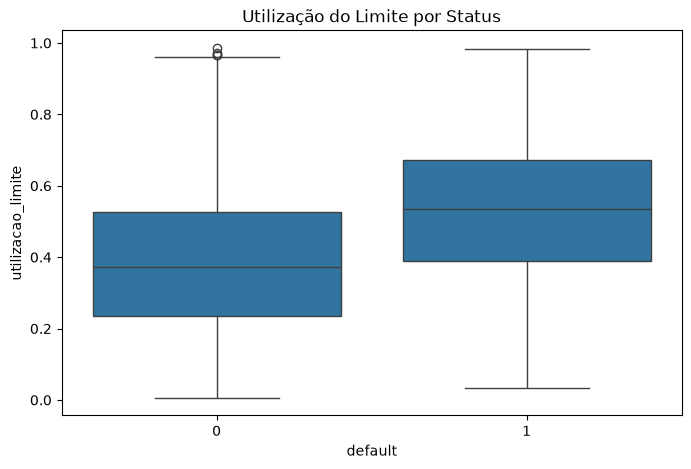

In [23]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    x="default",
    y="utilizacao_limite",
    data=df
)

plt.title(
    "Utilização do Limite por Status"
)

plt.show()

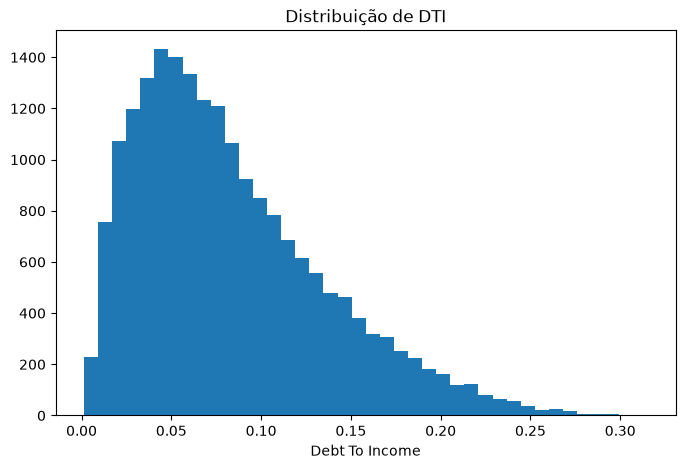

In [24]:
plt.figure(figsize=(8,5))

plt.hist(
    df["dti"],
    bins=40
)

plt.title(
    "Distribuição de DTI"
)

plt.xlabel("Debt To Income")

plt.show()

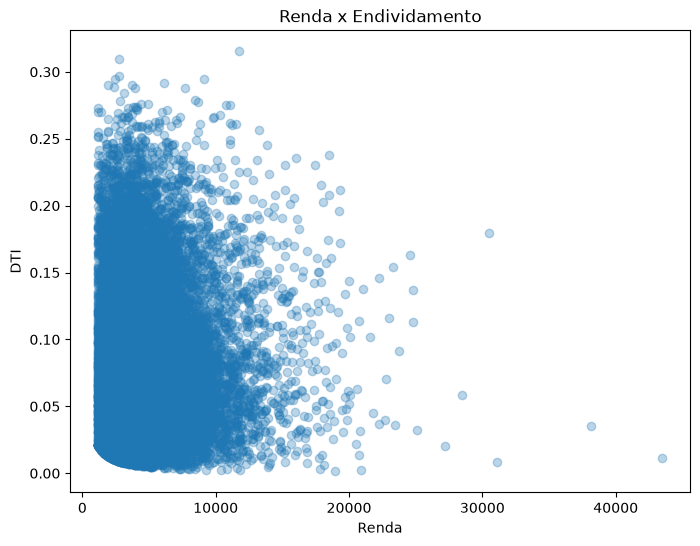

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["renda_mensal"],
    df["dti"],
    alpha=0.3
)

plt.xlabel("Renda")

plt.ylabel("DTI")

plt.title(
    "Renda x Endividamento"
)

plt.show()

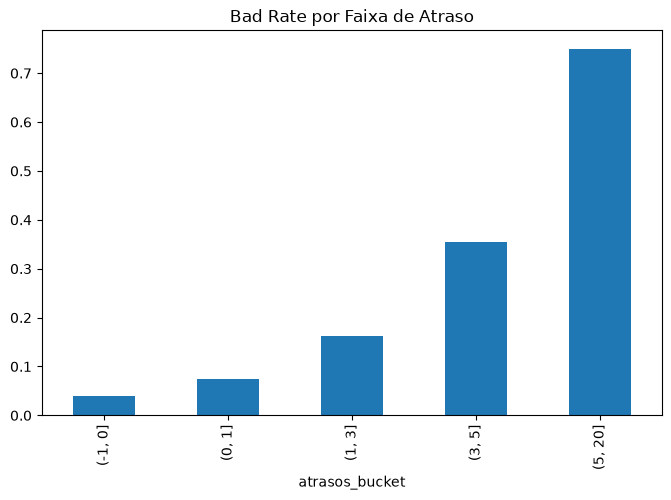

In [26]:
tmp = df.copy()

tmp["atrasos_bucket"] = pd.cut(
    tmp["atrasos_12m"],
    bins=[-1,0,1,3,5,20]
)

(
    tmp.groupby("atrasos_bucket")
    ["default"]
    .mean()
    .plot(
        kind="bar",
        figsize=(8,5)
    )
)

plt.title(
    "Bad Rate por Faixa de Atraso"
)

plt.show()

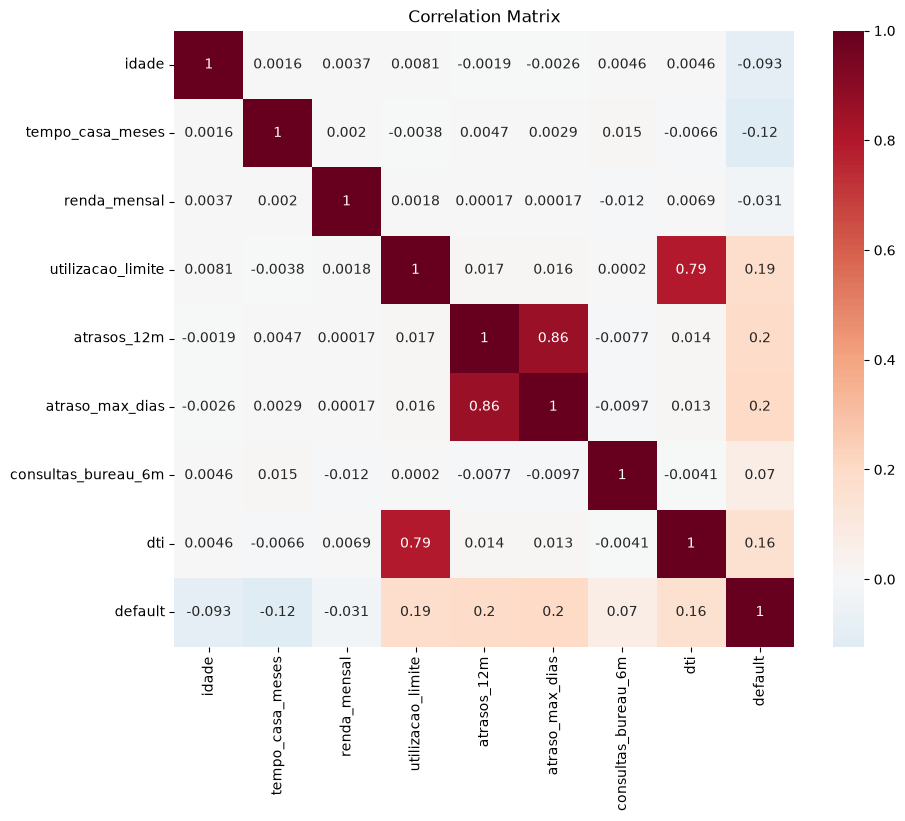

In [27]:
import seaborn as sns

corr = df[
    [
        "idade",
        "tempo_casa_meses",
        "renda_mensal",
        "utilizacao_limite",
        "atrasos_12m",
        "atraso_max_dias",
        "consultas_bureau_6m",
        "dti",
        "default"
    ]
].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r",
    center=0
)

plt.title(
    "Correlation Matrix"
)

plt.show()

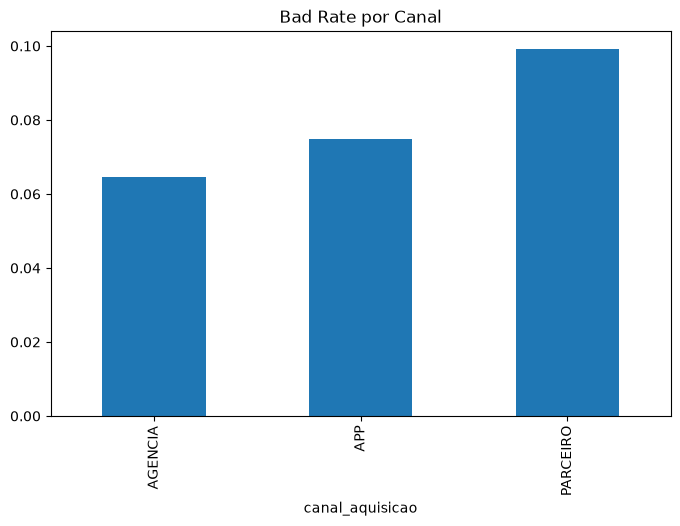

In [28]:
(
    df.groupby("canal_aquisicao")
    ["default"]
    .mean()
    .sort_values()
    .plot(
        kind="bar",
        figsize=(8,5)
    )
)

plt.title(
    "Bad Rate por Canal"
)

plt.show()

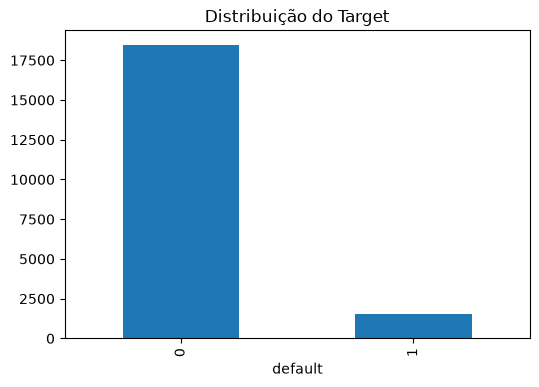

In [29]:
counts = (
    df["default"]
    .value_counts()
)

counts.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title(
    "Distribuição do Target"
)

plt.show()

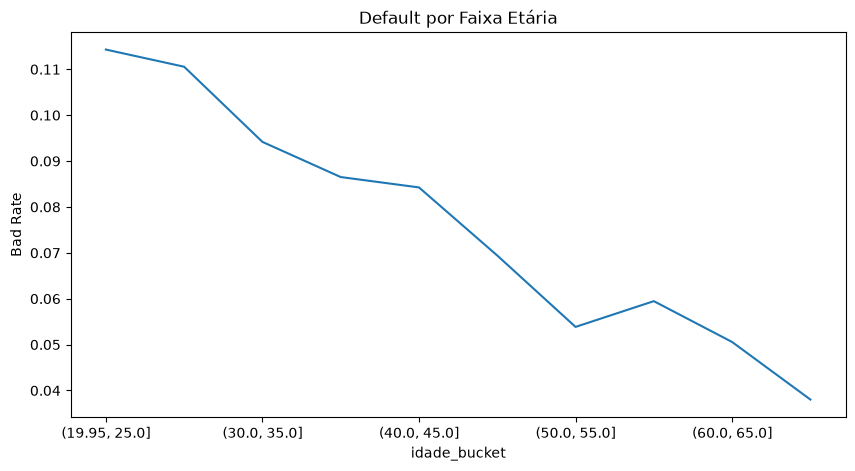

In [30]:
tmp = df.copy()

tmp["idade_bucket"] = pd.cut(
    tmp["idade"],
    bins=10
)

(
    tmp.groupby("idade_bucket")
    ["default"]
    .mean()
    .plot(
        figsize=(10,5)
    )
)

plt.title(
    "Default por Faixa Etária"
)

plt.ylabel("Bad Rate")

plt.show()